In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import os

# This is the safest way on Windows
local_path = r"C:\Users\MSI\Desktop\Thesis\Phi-3mini"

# Convert to absolute path and normalize
local_path = os.path.abspath(local_path)
print(f"Using absolute path: {local_path}")

# Verify the folder and files
if os.path.exists(local_path):
    print("✅ Folder exists!")
    files = os.listdir(local_path)
    print(f"Total files: {len(files)}")
    important = [f for f in files if any(x in f.lower() for x in ['model', 'config', 'tokenizer', 'phi3'])]
    print("Important files found:", important)
else:
    print("❌ Folder not found. Check the path above.")

print("\n" + "="*80)

# Load with extra safety
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    local_path,
    trust_remote_code=True,
    local_files_only=True
)

from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    local_path,
    trust_remote_code=True,
    local_files_only=True
)

print(config)
print(type(config))

print("Loading model... (expect 30-90 seconds on CPU)")
model = AutoModelForCausalLM.from_pretrained(
    local_path,
    trust_remote_code=True,
    #device_map="cpu",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
    local_files_only=True
)

print("\n🎉 SUCCESS! Phi-3 Mini is loaded from local folder.")

# Show the architecture
config = model.config
print("\n" + "="*80)
print("=== Phi-3 Mini Architecture Summary ===")
print(f"dimension of each token’s vector representation (d_model)          : {config.hidden_size}") # dimension of each token’s vector representation
print(f"Number of Transformer layers   : {config.num_hidden_layers}") #number of transformer blocks
print(f"MLP intermediate size: 3072 → 8192 → 3072          : {config.intermediate_size}")#size of the feed-forward network in each transformer block :3072 → 8192 → 3072
print(f"Attention heads                : {config.num_attention_heads}")
print(f"Key-Value heads (GQA)          : {getattr(config, 'num_key_value_heads', config.num_attention_heads)}")
print(f"Vocab size:Total number of tokens the model understands                     : {config.vocab_size}")#Total number of tokens the model understands
print(f"Max context length:Maximum number of tokens the model can process at once: {config.max_position_embeddings} tokens")#Maximum number of tokens the model can process at once
print(f"Activation                     : {config.hidden_act}")
print(f"Position encoding              : RoPE")
print(f"Normalization                  : RMSNorm")

Using absolute path: C:\Users\MSI\Desktop\Thesis\Phi-3mini
✅ Folder exists!
Total files: 10
Important files found: ['config.json', 'configuration_phi3.py', 'model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors', 'model.safetensors.index.json', 'modeling_phi3.py', 'tokenizer.json', 'tokenizer.model', 'tokenizer_config.json']

Loading tokenizer...


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
`torch_dtype` is deprecated! Use `dtype` instead!


Phi3Config {
  "architectures": [
    "Phi3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "auto_map": {
    "AutoConfig": "configuration_phi3.Phi3Config",
    "AutoModelForCausalLM": "modeling_phi3.Phi3ForCausalLM"
  },
  "bos_token_id": 1,
  "dtype": "bfloat16",
  "embd_pdrop": 0.0,
  "eos_token_id": 32000,
  "hidden_act": "silu",
  "hidden_size": 3072,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings": 131072,
  "model_type": "phi3",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 32,
  "original_max_position_embeddings": 4096,
  "pad_token_id": 32000,
  "resid_pdrop": 0.0,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "long_factor": [
      1.0700000524520874,
      1.1200000047683716,
      1.149999976158142,
      1.4199999570846558,
      1.5699999332427979,
      1.7999999523162842,
      2.129999876022339,
      2.129999876022339,
      3.009999990463257,
      5.9100003242492

`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading weights:   0%|          | 0/195 [00:01<?, ?it/s]


🎉 SUCCESS! Phi-3 Mini is loaded from local folder.

=== Phi-3 Mini Architecture Summary ===
dimension of each token’s vector representation (d_model)          : 3072
Number of Transformer layers   : 32
MLP intermediate size: 3072 → 8192 → 3072          : 8192
Attention heads                : 32
Key-Value heads (GQA)          : 32
Vocab size:Total number of tokens the model understands                     : 32064
Max context length:Maximum number of tokens the model can process at once: 131072 tokens
Activation                     : silu
Position encoding              : RoPE
Normalization                  : RMSNorm


The Model has a Hidden size of 3072 and it has 32 Transformer Layers and it has 8192 Multi Layer Perceptron Intermediate as a sie and it has 32 Attention Heads and 32 key -value heads (GQA) and it's Vocab Size it's 32064 and it's Max Context Length of Tokens is 131072 It's Position Encoding is Rotary Positional Encoding

In [8]:
print("\n" + "="*80)
print("=== Detailed Parameter Analysis ===")

hidden_size = config.hidden_size
num_layers = config.num_hidden_layers
intermediate_size = config.intermediate_size
vocab_size = config.vocab_size

# 🔹 Embedding parameters
embedding_params = vocab_size * hidden_size

# 🔹 Attention parameters per layer (Q, K, V, Output)
attention_params_per_layer = 4 * (hidden_size * hidden_size)

# 🔹 MLP parameters per layer
mlp_params_per_layer = (hidden_size * intermediate_size) + (intermediate_size * hidden_size)

# 🔹 Total per transformer block
params_per_block = attention_params_per_layer + mlp_params_per_layer

# 🔹 Total transformer parameters
total_transformer_params = params_per_block * num_layers

# 🔹 Total model params (approx)
total_params = total_transformer_params + embedding_params

print(f"Embedding parameters           : {embedding_params:,}")
print(f"Attention params per layer     : {attention_params_per_layer:,}")
print(f"MLP params per layer           : {mlp_params_per_layer:,}")
print(f"Total params per block         : {params_per_block:,}")
print(f"Total transformer params       : {total_transformer_params:,}")
print(f"Estimated total parameters     : {total_params:,}")


=== Detailed Parameter Analysis ===
Embedding parameters           : 98,500,608
Attention params per layer     : 37,748,736
MLP params per layer           : 50,331,648
Total params per block         : 88,080,384
Total transformer params       : 2,818,572,288
Estimated total parameters     : 2,917,072,896


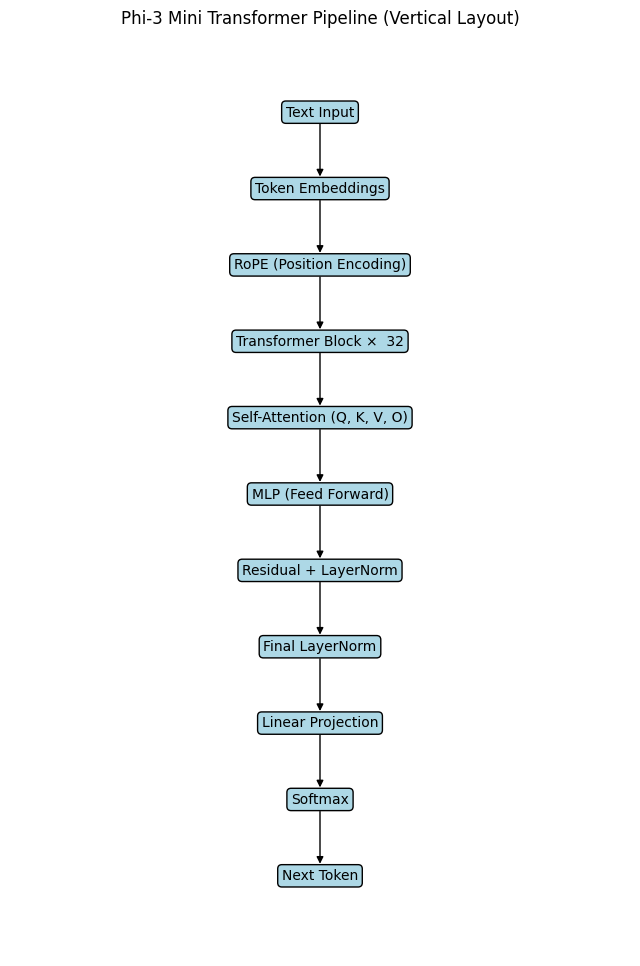

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

nodes = [
    "Text Input",
    "Token Embeddings",
    "RoPE (Position Encoding)",
    "Transformer Block ×  32",
    "Self-Attention (Q, K, V, O)",
    "MLP (Feed Forward)",
    "Residual + LayerNorm",
    "Final LayerNorm",
    "Linear Projection",
    "Softmax",
    "Next Token"
]

edges = [
    ("Text Input", "Token Embeddings"),
    ("Token Embeddings", "RoPE (Position Encoding)"),
    ("RoPE (Position Encoding)", "Transformer Block ×  32"),
    ("Transformer Block ×  32", "Self-Attention (Q, K, V, O)"),
    ("Self-Attention (Q, K, V, O)", "MLP (Feed Forward)"),
    ("MLP (Feed Forward)", "Residual + LayerNorm"),
    ("Residual + LayerNorm", "Final LayerNorm"),
    ("Final LayerNorm", "Linear Projection"),
    ("Linear Projection", "Softmax"),
    ("Softmax", "Next Token")
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize=(8, 12))

# 🔥 KEY FIX: vertical layout
pos = {node: (0, -i) for i, node in enumerate(nodes)}

# Draw edges
nx.draw_networkx_edges(G, pos, arrows=True)

# Draw rectangular nodes manually
for node, (x, y) in pos.items():
    plt.text(
        x, y,
        node,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#add8e6",
            edgecolor="black"
        )
    )

plt.title("Phi-3 Mini Transformer Pipeline (Vertical Layout)")
plt.axis("off")
plt.show()